# PyTorch Autograd for Beginners
This notebook teaches PyTorch autograd step by step in small sections.
We will learn:
- what autograd is
- forward propagation
- backward propagation
- gradient calculation
- weight updates
- learning rate
- training a small neural network with autograd

## 1. Setup
We start by importing PyTorch.
PyTorch tensors can store numbers, and autograd can track how computations are built from those numbers.

In [2]:
# Import the main PyTorch package
import torch

# Set a random seed so random numbers stay the same each time we run the notebook
torch.manual_seed(42)

# Print the PyTorch version so we know what environment we are using
print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cpu


## 2. What Is Autograd?
Autograd is PyTorch's automatic differentiation system.
It remembers how a result was created from earlier tensors, and then it can automatically compute gradients during backpropagation.
A gradient tells us how much a value should change to reduce the loss.

In [3]:
# Create a tensor that PyTorch should track for gradients
x = torch.tensor(3.0, requires_grad=True)

# Print the tensor itself
print('x:', x)

# requires_grad=True means autograd will remember operations done on x
print('Does x track gradients?', x.requires_grad)

x: tensor(3., requires_grad=True)
Does x track gradients? True


## 3. A Simple Forward Pass
Forward propagation means we start with an input and compute an output.
Here we use the small formula `y = x^2 + 2x + 1` to show how autograd builds a computation graph.

In [4]:
# Start with a single input value
x = torch.tensor(3.0, requires_grad=True)

# Compute x squared
x_squared = x ** 2

# Compute 2 times x
two_x = 2 * x

# Add everything to build y = x^2 + 2x + 1
y = x_squared + two_x + 1

# Print each step so the forward pass is easy to follow
print('x:', x)
print('x^2:', x_squared)
print('2x:', two_x)
print('y = x^2 + 2x + 1:', y)

x: tensor(3., requires_grad=True)
x^2: tensor(9., grad_fn=<PowBackward0>)
2x: tensor(6., grad_fn=<MulBackward0>)
y = x^2 + 2x + 1: tensor(16., grad_fn=<AddBackward0>)


## 4. Backward Propagation
Backward propagation starts from the output and moves backward through the graph.
Autograd applies the chain rule automatically and stores the gradient in `x.grad`.

In [24]:
# Recreate the same input so this cell can run independently
x = torch.tensor(3.0, requires_grad=True)

# Recreate the same forward-pass formula
y = x ** 2 + 2 * x + 1

# Run backward propagation
# Because y is a single number, PyTorch can compute dy/dx directly
y.backward()

# The gradient is stored in x.grad
print('y:', y)
# The X value will be as it is but the gradient will be stored in x.grad
print('Gradient dy/dx at x = 3:', x.grad)

# For y = x^2 + 2x + 1, the derivative is dy/dx = 2x + 2
# At x = 3, the answer should be 8
print('Expected gradient from math:', 2 * 3 + 2)

y: tensor(16., grad_fn=<AddBackward0>)
Gradient dy/dx at x = 3: tensor(8.)
Expected gradient from math: 8


## 5. Gradients Accumulate
By default, PyTorch adds new gradients to the existing gradient buffer.
That is why training loops often clear gradients before the next backward pass.

In [25]:
# Create a tensor that tracks gradients
x = torch.tensor(2.0, requires_grad=True)

# First computation and backward pass
y1 = x ** 2
y1.backward()
print('Gradient after first backward pass:', x.grad)

# Second computation uses the same tensor
y2 = 3 * x
y2.backward()
print('Gradient after second backward pass:', x.grad)

# The value is now accumulated: 4 + 3 = 7.
# if we dont reset the gradients, they will accumulate and give us the wrong answer.
# This is why we often reset gradients during training.

Gradient after first backward pass: tensor(4.)
Gradient after second backward pass: tensor(7.)


## 6. Chain Rule With Multiple Steps
Autograd works because it applies the chain rule through every operation.
We will build a small expression step by step and then compute the final gradient automatically.

In [7]:
# Start from an input value
x = torch.tensor(2.0, requires_grad=True)

# Step 1: a = x^2
a = x ** 2

# Step 2: b = 3a
b = 3 * a

# Step 3: c = b + 4
c = b + 4

# Backward pass computes dc/dx automatically
c.backward()

# Print every intermediate result
print('a = x^2:', a)
print('b = 3a:', b)
print('c = b + 4:', c)
print('Gradient dc/dx:', x.grad)

# By math: c = 3x^2 + 4, so dc/dx = 6x
# At x = 2, the expected gradient is 12
print('Expected gradient from math:', 6 * 2)

a = x^2: tensor(4., grad_fn=<PowBackward0>)
b = 3a: tensor(12., grad_fn=<MulBackward0>)
c = b + 4: tensor(16., grad_fn=<AddBackward0>)
Gradient dc/dx: tensor(12.)
Expected gradient from math: 12


## 7. Forward Propagation of One Simple Neuron
A single neuron often computes `prediction = weight * input + bias`.
This is the basic building block behind larger neural networks.

In [27]:
# Create an input value
input_value = torch.tensor(4.0)

# Create trainable parameters
weight = torch.tensor(2.0, requires_grad=True)
bias = torch.tensor(1.0, requires_grad=True)

# Forward propagation formula: prediction = weight * input + bias
prediction = weight * input_value + bias

# Print the result
print('Input:', input_value)
print('Weight:', weight)
print('Bias:', bias)
print('Prediction:', prediction)

Input: tensor(4.)
Weight: tensor(2., requires_grad=True)
Bias: tensor(1., requires_grad=True)
Prediction: tensor(9., grad_fn=<AddBackward0>)


## 8. Loss and Backward Propagation
Training needs a loss function that measures how wrong the prediction is.
We will use mean squared error in a very small form: `loss = (prediction - target)^2`.

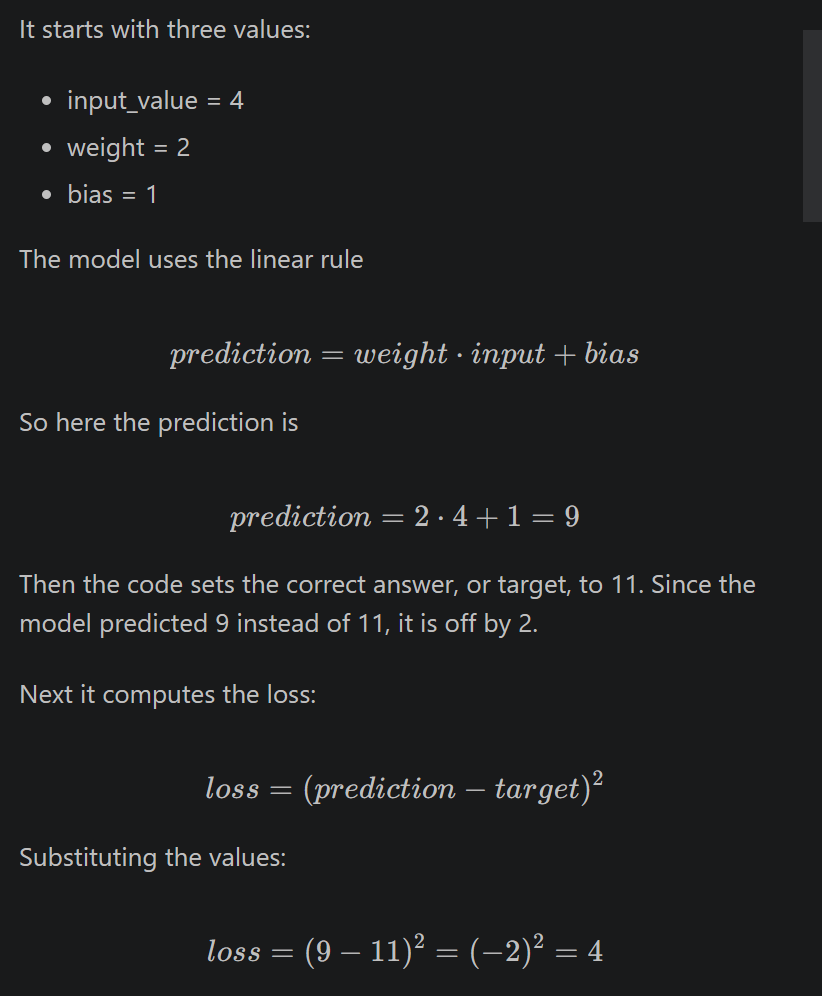

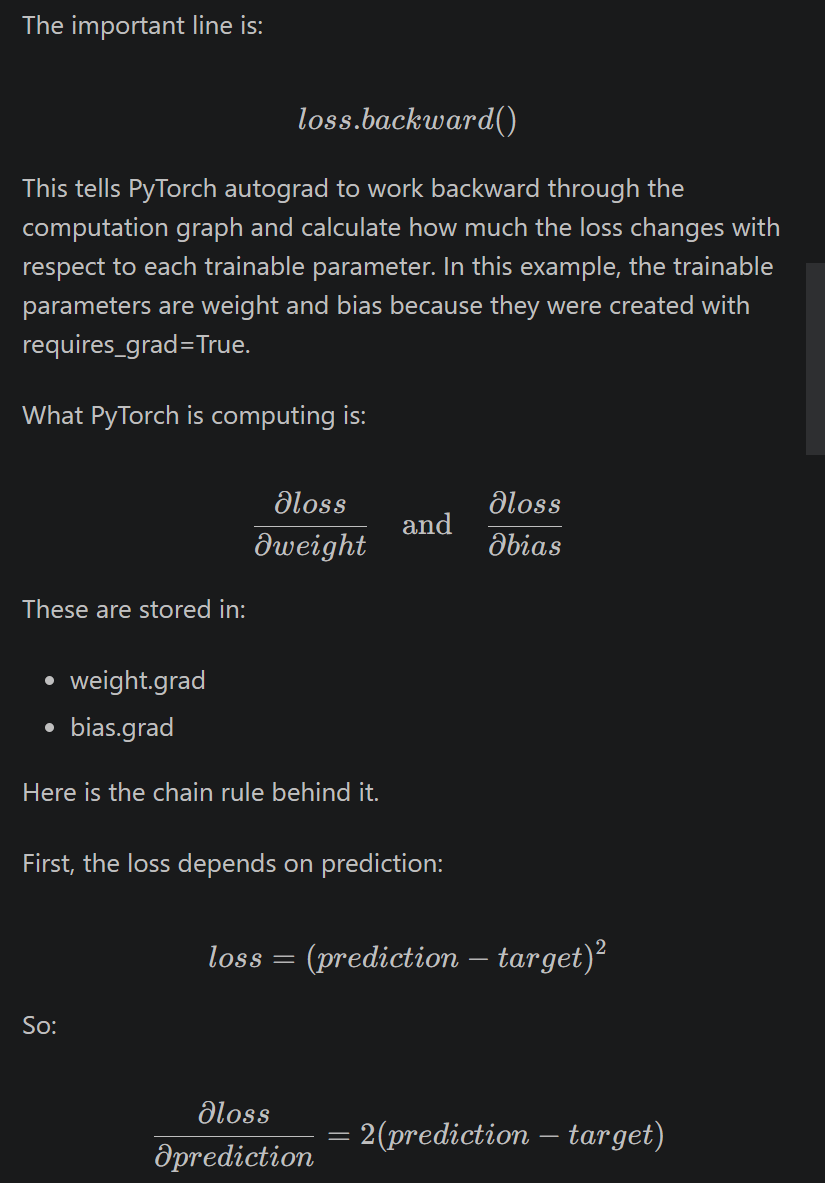

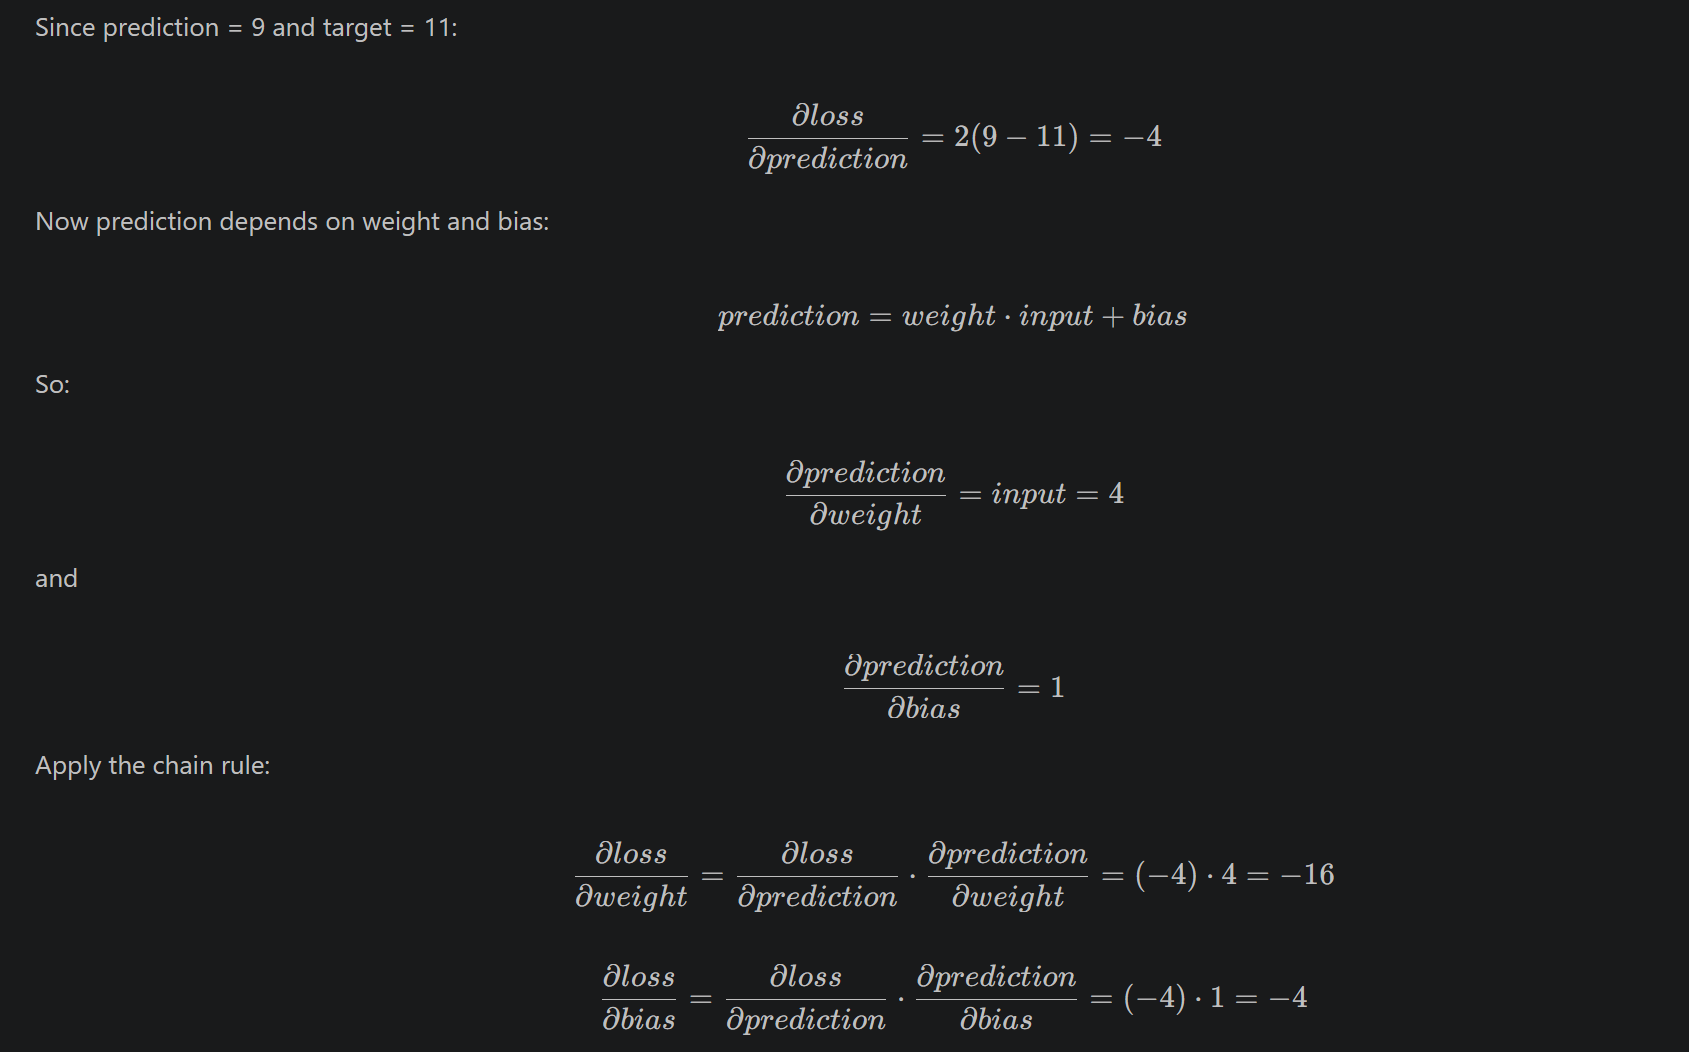

In [28]:
# Use the same input and parameters
# These all are the concepts of the Partial Derivatives and the Chain Rule in Calculus.
input_value = torch.tensor(4.0)
weight = torch.tensor(2.0, requires_grad=True)
bias = torch.tensor(1.0, requires_grad=True)

# Forward pass
prediction = weight * input_value + bias

# Assume the correct target value should be 11
target = torch.tensor(11.0)

# Mean squared error for one example: loss = (prediction - target)^2
loss = (prediction - target) ** 2

# Backward pass computes gradients for weight and bias
loss.backward()

# Print the loss and gradients
print('Prediction:', prediction)
print('Target:', target)
print('Loss:', loss)
print('Gradient of loss with respect to weight:', weight.grad)
print('Gradient of loss with respect to bias:', bias.grad)

# loss = (weight * input_value + bias - target) ** 2
# d(loss)/d(weight) = 2 * ((weight * input_value + bias - target) * input_value)
#                   =  2 * ((2 * 4 + 1 - 11) * 4)
#                   = 2 * ((8 + 1 - 11) * 4) 
#                     = 2 * ((-2) * 4)
#                     = -16


Prediction: tensor(9., grad_fn=<AddBackward0>)
Target: tensor(11.)
Loss: tensor(4., grad_fn=<PowBackward0>)
Gradient of loss with respect to weight: tensor(-16.)
Gradient of loss with respect to bias: tensor(-4.)


## 9. Weight Update
After gradients are computed, we update the parameters in the opposite direction of the gradient.
If a gradient is positive, we usually subtract from the parameter. If it is negative, we usually add.

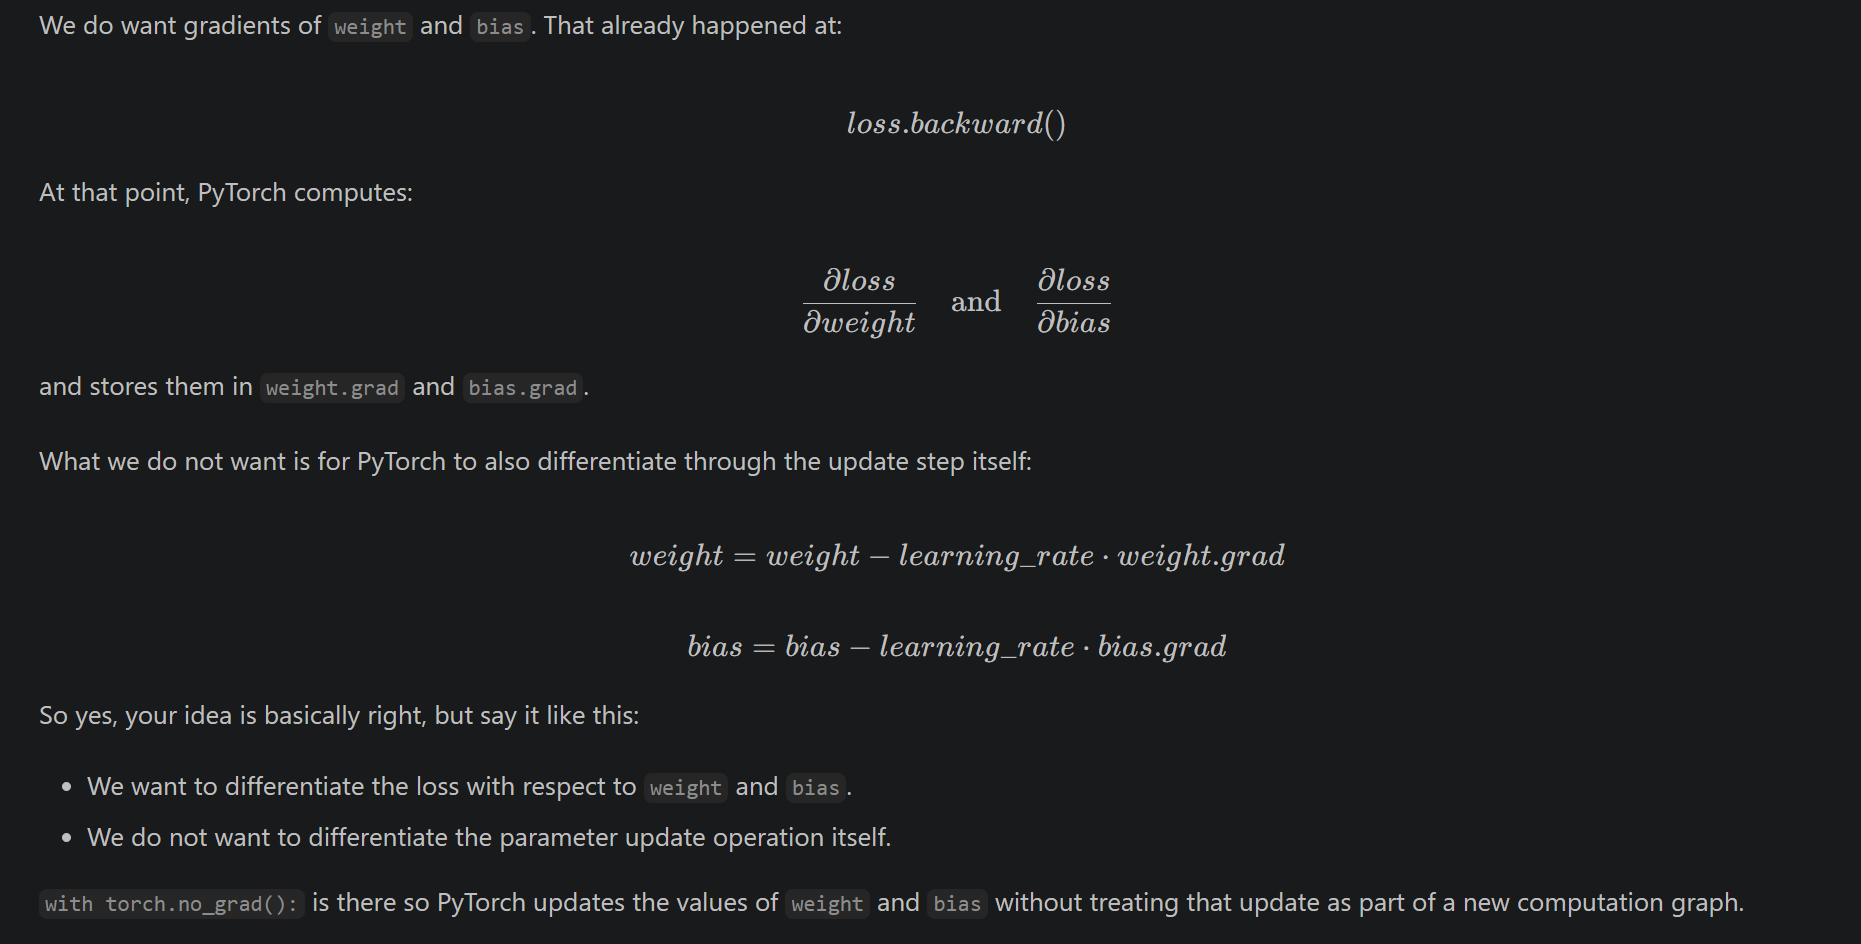

In [31]:
# Use the same tiny example again
input_value = torch.tensor(4.0)
target = torch.tensor(11.0)

# Create trainable parameters
weight = torch.tensor(2.0, requires_grad=True)
bias = torch.tensor(1.0, requires_grad=True)

# Forward pass
prediction = weight * input_value + bias
loss = (prediction - target) ** 2

# Backward pass
loss.backward()

# Set a learning rate
learning_rate = 0.1

# Update the parameters, but do not let PyTorch record these update steps.
# We already used autograd to compute the gradients above with loss.backward().
# Now we only want to change the values of weight and bias for the next step.
# If PyTorch tracked this update, it would build a new graph for the update itself, which we do not want here.
with torch.no_grad():
    weight = weight - learning_rate * weight.grad
    bias = bias - learning_rate * bias.grad

# Print updated parameters
print('Updated weight:', weight)
print('Updated bias:', bias)

Updated weight: tensor(3.6000)
Updated bias: tensor(1.4000)


In [41]:
# Create a starting value for the weight, and tell PyTorch to track gradients for it.
weight = torch.tensor(2.0, requires_grad=True)
# Create a starting value for the bias, and tell PyTorch to track gradients for it too.
bias = torch.tensor(1.0, requires_grad=True)

# Create the input value that will go into the neuron.
input_value = torch.tensor(4.0)
# Create the correct answer that we want the model to reach.
target = torch.tensor(11.0)

# Choose how big each update step should be.
learning_rate = 0.01
# Choose how many times we want to repeat the training step.
n = 100

# Repeat the same training process many times.
for i in range(n):
    # Compute the prediction using the current weight and bias.
    prediction = weight * input_value + bias
    # Measure how wrong the prediction is.
    loss = (prediction - target) ** 2
    # Ask PyTorch to compute gradients for weight and bias.
    loss.backward()

    # Update the values, but do not track this update as part of a new graph.
    with torch.no_grad():
        # Move the weight in the direction that reduces the loss.
        weight -= learning_rate * weight.grad
        # Move the bias in the direction that reduces the loss.
        bias -= learning_rate * bias.grad

        # Clear the old gradient of weight so the next loop starts fresh.
        weight.grad.zero_()
        # Clear the old gradient of bias so the next loop starts fresh.
        bias.grad.zero_()
        # Print the current loss so we can watch it get smaller.
        print(loss)

# Print the final weight after training.
print(weight)
# Print the final bias after training.
print(bias)

tensor(4., grad_fn=<PowBackward0>)
tensor(1.7424, grad_fn=<PowBackward0>)
tensor(0.7590, grad_fn=<PowBackward0>)
tensor(0.3306, grad_fn=<PowBackward0>)
tensor(0.1440, grad_fn=<PowBackward0>)
tensor(0.0627, grad_fn=<PowBackward0>)
tensor(0.0273, grad_fn=<PowBackward0>)
tensor(0.0119, grad_fn=<PowBackward0>)
tensor(0.0052, grad_fn=<PowBackward0>)
tensor(0.0023, grad_fn=<PowBackward0>)
tensor(0.0010, grad_fn=<PowBackward0>)
tensor(0.0004, grad_fn=<PowBackward0>)
tensor(0.0002, grad_fn=<PowBackward0>)
tensor(8.1323e-05, grad_fn=<PowBackward0>)
tensor(3.5414e-05, grad_fn=<PowBackward0>)
tensor(1.5431e-05, grad_fn=<PowBackward0>)
tensor(6.7189e-06, grad_fn=<PowBackward0>)
tensor(2.9272e-06, grad_fn=<PowBackward0>)
tensor(1.2750e-06, grad_fn=<PowBackward0>)
tensor(5.5618e-07, grad_fn=<PowBackward0>)
tensor(2.4216e-07, grad_fn=<PowBackward0>)
tensor(1.0514e-07, grad_fn=<PowBackward0>)
tensor(4.6043e-08, grad_fn=<PowBackward0>)
tensor(1.9922e-08, grad_fn=<PowBackward0>)
tensor(8.7348e-09, grad_

## 10. Learning Rate
The learning rate controls the step size during parameter updates.
If the learning rate is too large, training may jump around and become unstable.
If the learning rate is too small, training may be very slow.

In [11]:
# Use the same gradient value with two different learning rates
gradient_example = torch.tensor(5.0)
start_weight = torch.tensor(2.0)

# Small learning rate makes a small step
small_lr = 0.01
small_step_weight = start_weight - small_lr * gradient_example

# Large learning rate makes a much bigger step
large_lr = 0.5
large_step_weight = start_weight - large_lr * gradient_example

# Print both updates for comparison
print('Start weight:', start_weight)
print('Weight after small learning rate:', small_step_weight)
print('Weight after large learning rate:', large_step_weight)

Start weight: tensor(2.)
Weight after small learning rate: tensor(1.9500)
Weight after large learning rate: tensor(-0.5000)


## 11. Training Data for a Tiny Neural Network
Now we move from one manual example to a small learning task.
We will teach a tiny neural network the rule `y = 2x + 1` from example data.

In [46]:
# Create input data with shape (number_of_examples, number_of_features)
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])

# Create target values for the rule y = 2x + 1
y_true = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

# Print the dataset
print('Inputs:\n', X)
print('Targets:\n', y_true)

Inputs:
 tensor([[1.],
        [2.],
        [3.],
        [4.]])
Targets:
 tensor([[3.],
        [5.],
        [7.],
        [9.]])


## 12. Build a Tiny Neural Network
We will use two linear layers with a ReLU activation in the middle.
Autograd will track all operations automatically because the parameters inside the model require gradients.

In [47]:
# Build a tiny neural network by stacking layers in order.
model = torch.nn.Sequential(
    # First layer: take 1 input feature and produce 4 outputs.
    torch.nn.Linear(1, 4),
    # ReLU keeps positive values and changes negative values to zero.
    torch.nn.ReLU(),
    # Second layer: take the 4 values and turn them into 1 output.
    torch.nn.Linear(4, 1)
)

# Print the model structure so we can see the layers.
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)


## 13. One Forward Pass Through the Neural Network
The forward pass means sending input data through the network to get predictions.
We also compute the loss to measure how far the predictions are from the correct answers.

In [48]:
# Define a mean squared error loss function
loss_fn = torch.nn.MSELoss()

# Make predictions using the current model parameters
predictions = model(X)

# Compare predictions with the correct targets
loss = loss_fn(predictions, y_true)

# Print the predictions and the loss
print('Predictions before training:\n', predictions)
print('Loss before training:', loss.item())

Predictions before training:
 tensor([[-0.7779],
        [-1.0662],
        [-1.4775],
        [-1.8889]], grad_fn=<AddmmBackward0>)
Loss before training: 60.37680435180664


## 14. Backward Pass for the Neural Network
Now we call `backward()` on the loss.
Autograd computes gradients for every parameter in the network.

In [49]:
# Clear old gradients before a new backward pass
model.zero_grad()

# Run backward propagation from the loss
loss.backward()

# Look at the gradient of the first layer weights
first_layer_weight_grad = model[0].weight.grad

# Print one gradient tensor as proof that autograd worked
print('Gradient of first layer weights:\n', first_layer_weight_grad)
print('Loss after first layer:', loss.item())

Gradient of first layer weights:
 tensor([[ 0.0000],
        [21.0522],
        [ 0.0000],
        [ 0.6353]])
Loss after first layer: 60.37680435180664


## 15. Manual Parameter Update for the Neural Network
We now update the model parameters by hand using the gradients.
This exposes the core learning rule clearly: `parameter = parameter - learning_rate * gradient`.

In [16]:
# Choose a learning rate for training
learning_rate = 0.01

# Update every parameter manually without tracking the update in autograd
with torch.no_grad():
    for parameter in model.parameters():
        parameter -= learning_rate * parameter.grad

# Make new predictions after one update step
updated_predictions = model(X)
updated_loss = loss_fn(updated_predictions, y_true)

# Print the new loss to see whether it improved
print('Loss after one manual update:', updated_loss.item())

Loss after one manual update: 10.050256729125977


## 16. Full Training Loop
Now we repeat forward pass, loss calculation, backward pass, and parameter update many times.
This is the standard training cycle used in neural networks.

In [17]:
# Recreate the model so training starts fresh
model = torch.nn.Sequential(
    torch.nn.Linear(1, 4),
    torch.nn.ReLU(),
    torch.nn.Linear(4, 1)
)

# Recreate the loss function
loss_fn = torch.nn.MSELoss()

# Set the learning rate and number of training steps
learning_rate = 0.01
epochs = 500

# Repeat the training steps many times
for epoch in range(epochs):
    # Forward pass: compute predictions
    predictions = model(X)

    # Compute loss
    loss = loss_fn(predictions, y_true)

    # Clear old gradients before computing new ones
    model.zero_grad()

    # Backward pass: compute gradients
    loss.backward()

    # Update parameters manually
    with torch.no_grad():
        for parameter in model.parameters():
            parameter -= learning_rate * parameter.grad

    # Print progress every 100 steps
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}, Loss: {loss.item():.6f}')

Epoch 100, Loss: 0.004557
Epoch 200, Loss: 0.000528
Epoch 300, Loss: 0.000062
Epoch 400, Loss: 0.000007
Epoch 500, Loss: 0.000001


## 17. Test the Trained Neural Network
After training, we check whether the network has learned the pattern.
If training worked well, the predictions should be close to `2x + 1`.

In [18]:
# Turn off gradient tracking during evaluation
with torch.no_grad():
    # Ask the model to predict outputs for the training inputs
    final_predictions = model(X)

# Print predicted and expected values side by side
print('Final predictions:\n', final_predictions)
print('Expected targets:\n', y_true)

Final predictions:
 tensor([[2.9985],
        [4.9993],
        [7.0000],
        [9.0008]])
Expected targets:
 tensor([[3.],
        [5.],
        [7.],
        [9.]])


## 18. Key Ideas to Remember
- Forward propagation computes predictions from inputs.
- The loss function measures how wrong the predictions are.
- Backward propagation computes gradients.
- Gradients tell us how to change weights and biases.
- The learning rate controls how large each update step is.
- Repeating these steps trains the neural network.

## 19. Practice Ideas
1. Change the learning rate and observe whether training becomes faster or unstable.
2. Increase the number of epochs and compare the final loss.
3. Change the target rule from `y = 2x + 1` to another simple formula and retrain the model.

In [88]:
# now after training the neural network , we have to get weight as 10 and bias as 20 to get the target value as 60 when input is 4.

x_new = torch.tensor([[4.0] , [5.0] , [6.0]])

# print(formulae)

loss = torch.nn.MSELoss()
target = torch.tensor([[8.0] , [10.0] , [12.0]])

model = torch.nn.Sequential(
    torch.nn.Linear(1,5),
    torch.nn.ReLU(),
    torch.nn.Linear(5,1)
)
prediction = model(x_new)

print("The Loss before training is" , loss(prediction, target))
print("The prediction before training is" , prediction)


The Loss before training is tensor(81.6405, grad_fn=<MseLossBackward0>)
The prediction before training is tensor([[0.9389],
        [1.0913],
        [1.2437]], grad_fn=<AddmmBackward0>)


In [91]:
n = 500
learning_rate = 0.01

for i in range(n):
    prediction = model(x_new)
    loss_value = loss(prediction, target)
    model.zero_grad()
    loss_value.backward()
    with torch.no_grad():
        for parameter in model.parameters():
            parameter -= learning_rate * parameter.grad

with torch.no_grad():
    prediction = model(x_new)

print("The Loss after training is" , loss(prediction, target))
print("The prediction after training is" , prediction)


The Loss after training is tensor(0.0863)
The prediction after training is tensor([[ 8.2642],
        [10.2928],
        [12.3215]])
